#Part III Language Tasks

###(Sentiment Analysis) Text Classification with RNN

##Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import itertools

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [2]:
!pip install contractions -q
import contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.3 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Load the datasets

In [5]:
train_df = pd.read_csv('/content/drive/MyDrive/assesment/5. Movie Review Dataset/train_movie_review.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/assesment/5. Movie Review Dataset/val_movie_review.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/assesment/5. Movie Review Dataset/test_movie_review.csv')



In [6]:
# Drop rows with missing sentiment (unlabelled data per dataset description)
train_df = train_df.dropna(subset=['review', 'sentiment'])
val_df   = val_df.dropna(subset=['review', 'sentiment'])
test_df  = test_df.dropna(subset=['review', 'sentiment'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df.head()


Train: 35000 | Val: 5000 | Test: 10000


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [8]:
#Data info
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  35000 non-null  int64 
 1   review      35000 non-null  object
 2   sentiment   35000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 820.4+ KB
None


In [9]:
print("\nMissing Values")
print(train_df.isnull().sum())


Missing Values
Unnamed: 0    0
review        0
sentiment     0
dtype: int64


Sentiment Distribution in Training Set
sentiment
0    17584
1    17416
Name: count, dtype: int64


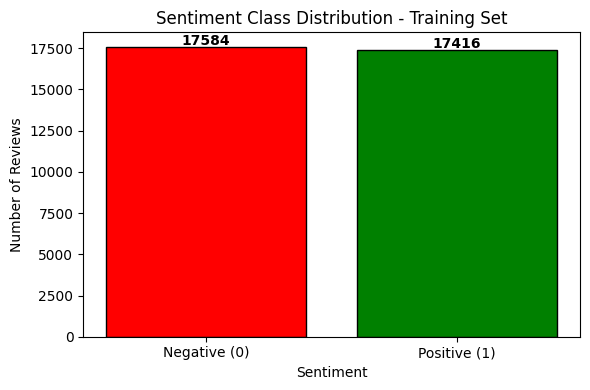

In [10]:
print("Sentiment Distribution in Training Set")
print(train_df['sentiment'].value_counts())

labels = ['Negative (0)', 'Positive (1)']
counts = train_df['sentiment'].value_counts().sort_index().values

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['red', 'green'], edgecolor='black')
plt.title('Sentiment Class Distribution - Training Set')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Review Length Statistics (Word Count)
count    35000.000000
mean       230.728714
std        170.956346
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


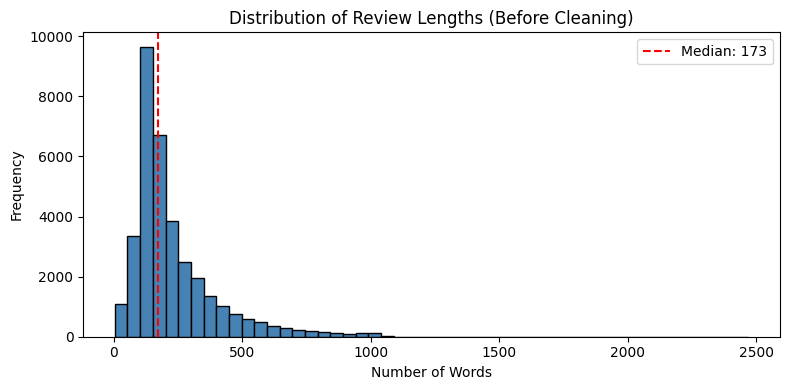

In [11]:
# Review Length Analysis (before cleaning)
train_df['review_length'] = train_df['review'].apply(lambda x: len(str(x).split()))

print("Review Length Statistics (Word Count)")
print(train_df['review_length'].describe())

plt.figure(figsize=(8, 4))
plt.hist(train_df['review_length'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Review Lengths (Before Cleaning)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(train_df['review_length'].median(), color='red',
            linestyle='dashed', label=f"Median: {train_df['review_length'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()





##Data Preprocessing

Before feeding text into any neural network, raw reviews need cleaning.

In [12]:
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text):
    """
    Full cleaning pipeline for movie review text.
    Steps:
        1. Lowercase
        2. Remove HTML tags (e.g. <br />)
        3. Expand contractions
        4. Remove URLs
        5. Remove special characters and punctuation
        6. Remove numbers
        7. Remove extra whitespace
        8. Remove stopwords and lemmatize
    """
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)                          # Remove HTML
    text = contractions.fix(text)                               # Expand contractions
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'[^\w\s]', '', text)                         # Remove special chars
    text = re.sub(r'\d+', '', text)                             # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()                    # Remove extra whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)



In [13]:

train_df['cleaned_review'] = train_df['review'].apply(preprocess_text)
val_df['cleaned_review']   = val_df['review'].apply(preprocess_text)
test_df['cleaned_review']  = test_df['review'].apply(preprocess_text)


In [14]:
print(train_df[['review', 'cleaned_review']].head(5))

                                              review  \
0  Having avoided seeing the movie in the cinema,...   
1  With this movie I was really hoping that the i...   
2  Raymond Burr stars as an attorney caught up in...   
3  A lot people get hung up on this films tag as ...   
4  I was a fan of Buffy and hoped it would come t...   

                                      cleaned_review  
0  avoided seeing movie cinema buying dvd wife xm...  
1  movie really hoping idea make hashed together ...  
2  raymond burr star attorney caught murder best ...  
3  lot people get hung film tag childrens film ce...  
4  fan buffy hoped would come proper end angel go...  


In [15]:
# Drop empty reviews after cleaning
train_df = train_df[train_df['cleaned_review'].str.strip() != '']
val_df   = val_df[val_df['cleaned_review'].str.strip() != '']
test_df  = test_df[test_df['cleaned_review'].str.strip() != '']

print(f"Training samples after cleaning   : {len(train_df)}")
print(f"Validation samples after cleaning  : {len(val_df)}")
print(f"Test samples after cleaning        : {len(test_df)}")

Training samples after cleaning   : 35000
Validation samples after cleaning  : 5000
Test samples after cleaning        : 10000


##Data Visualization

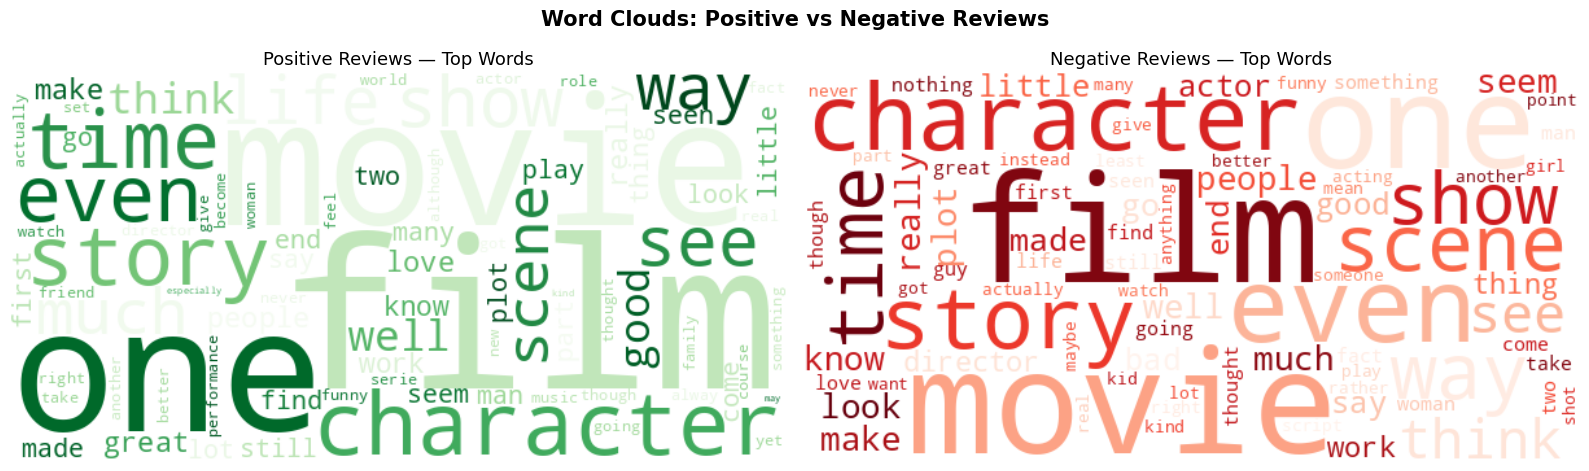

In [16]:
# Word Cloud: Positive vs Negative Reviews
positive_words = ' '.join(train_df[train_df['sentiment'] == 1]['cleaned_review'])
negative_words = ' '.join(train_df[train_df['sentiment'] == 0]['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='Greens').generate(positive_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews — Top Words', fontsize=13)

wc_neg = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='Reds').generate(negative_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews — Top Words', fontsize=13)

plt.suptitle('Word Clouds: Positive vs Negative Reviews', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

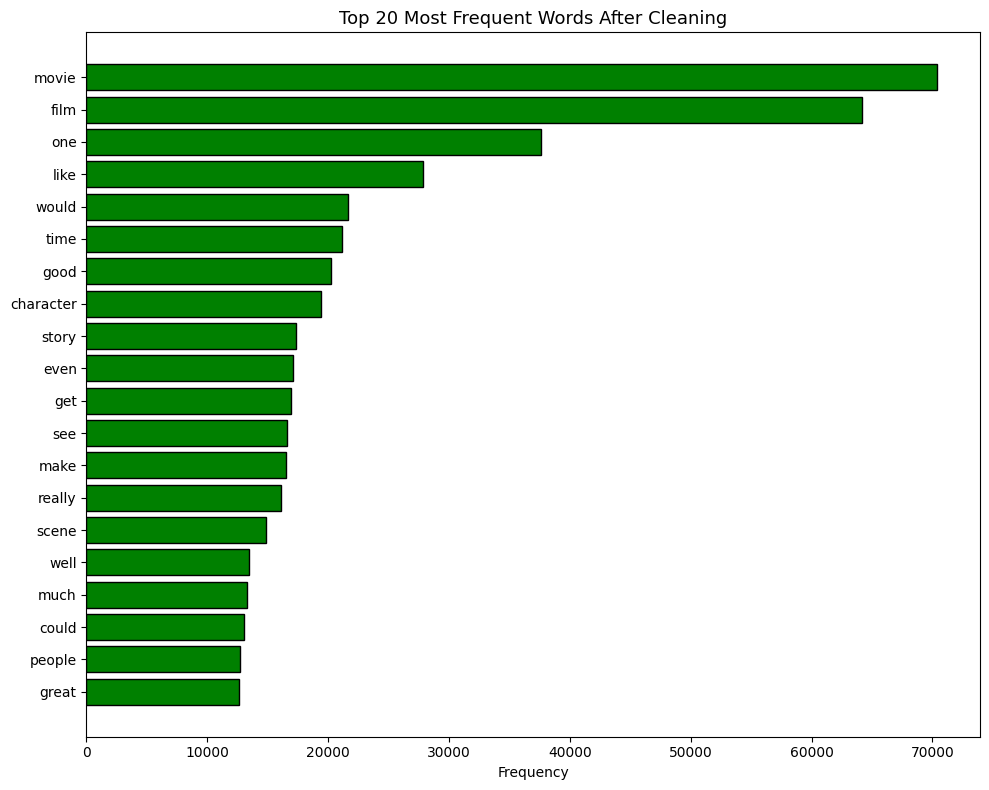

In [17]:
# Bar Chart: Top 20 Most Frequent Words
all_tokens = ' '.join(train_df['cleaned_review']).split()
word_freq  = Counter(all_tokens)
top_20     = word_freq.most_common(20)

words  = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(10, 8))
plt.barh(words[::-1], counts[::-1], color='green', edgecolor='black')
plt.title('Top 20 Most Frequent Words After Cleaning', fontsize=13)
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

##Tokenisation and Padding

We cap at the top 10,000 most frequent words, rare words becone out of vocabulary. Crucially, the tokenizer is fitted only on training data to prevent data leakage

In [20]:
# Prepare Features and Labels
X_train = train_df['cleaned_review'].values
y_train = train_df['sentiment'].values

X_val   = val_df['cleaned_review'].values
y_val   = val_df['sentiment'].values

X_test  = test_df['cleaned_review'].values
y_test  = test_df['sentiment'].values

print(f"X_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"X_val shape  : {X_val.shape}    |  y_val shape  : {y_val.shape}")
print(f"X_test shape : {X_test.shape}   |  y_test shape : {y_test.shape}")

X_train shape: (35000,)  |  y_train shape: (35000,)
X_val shape  : (5000,)    |  y_val shape  : (5000,)
X_test shape : (10000,)   |  y_test shape : (10000,)


In [21]:
VOCAB_SIZE = 10000  # Maximum vocabulary size

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # Fit ONLY on training data

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

actual_vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size learned from training data : {actual_vocab_size}")
print(f"Vocabulary size used (capped)              : {VOCAB_SIZE}")
print()


Vocabulary size learned from training data : 122281
Vocabulary size used (capped)              : 10000



##Sequence Padding

NN need fixed-length inputs. so, we use 95th percentile of training sequence lengths as MAX_LEN, this covers 95% of reviews without wasting memory on extreme outliers. Shorter sequences get zero-padded at the end (post), longer oen get truncated at the end.

Min length    : 4
Max length    : 1416
Mean length   : 116.5
Median length : 87.0
95th Pctile   : 301


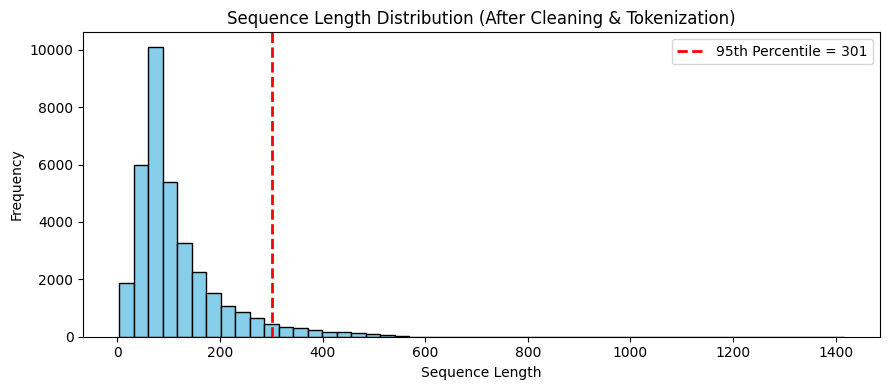

In [24]:
seq_lengths = [len(seq) for seq in X_train_seq]

print(f"Min length    : {np.min(seq_lengths)}")
print(f"Max length    : {np.max(seq_lengths)}")
print(f"Mean length   : {np.mean(seq_lengths):.1f}")
print(f"Median length : {np.median(seq_lengths):.1f}")
print(f"95th Pctile   : {np.percentile(seq_lengths, 95):.0f}")

plt.figure(figsize=(9, 4))
plt.hist(seq_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Sequence Length Distribution (After Cleaning & Tokenization)')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed', linewidth=2,
            label=f"95th Percentile = {int(np.percentile(seq_lengths, 95))}")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f"Padding all sequences to max length: {MAX_LEN} tokens")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_val_pad shape   : {X_val_pad.shape}")
print(f"X_test_pad shape  : {X_test_pad.shape}")

Padding all sequences to max length: 301 tokens
X_train_pad shape : (35000, 301)
X_val_pad shape   : (5000, 301)
X_test_pad shape  : (10000, 301)


##Model 1 - Simple RNN with Trainable Embedding Layer

It faces the vanishing gradient problem. During back propagation, gradients shrink exponentially as they travel back through hundreds of time steps. By the time the model tries to learn from the beginning of a long review, and gradient becomes zero, this is exactly where simple RNN fails.

Expected accuracy: ~50% (random baseline)

In [26]:
EMBEDDING_DIM = 256

rnn_model = Sequential(name='Simple_RNN_Model')
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)) #passes its full output sequence to second layer
rnn_model.add(SimpleRNN(units=128, return_sequences=True))
rnn_model.add(Dropout(0.3))
rnn_model.add(SimpleRNN(units=64,  return_sequences=False))  #return final hidden state
rnn_model.add(Dropout(0.5))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "Simple_RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 301, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 301, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 301, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,697 (10.00 MB)

 Trainable params: 2,621,697 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)


In [28]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True, verbose=1)

checkpoint_rnn = ModelCheckpoint('best_rnn_model.keras',
                                 monitor='val_accuracy',
                                 save_best_only=True, mode='max', verbose=1)

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_rnn],
    verbose=1
)

Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4948 - loss: 0.7473
Epoch 1: val_accuracy improved from None to 0.50700, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.4969 - loss: 0.7434 - val_accuracy: 0.5070 - val_loss: 0.6939
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4938 - loss: 0.7285
Epoch 2: val_accuracy did not improve from 0.50700
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.4943 - loss: 0.7230 - val_accuracy: 0.4984 - val_loss: 0.6941
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4948 - loss: 0.7085
Epoch 3: val_accuracy improved from 0.50700 to 0.50860, saving model to best_rnn_model.keras

Epoch 3: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.4984 - loss: 0.7039 - val_accuracy: 0.5086 - val_loss: 0.6950
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━

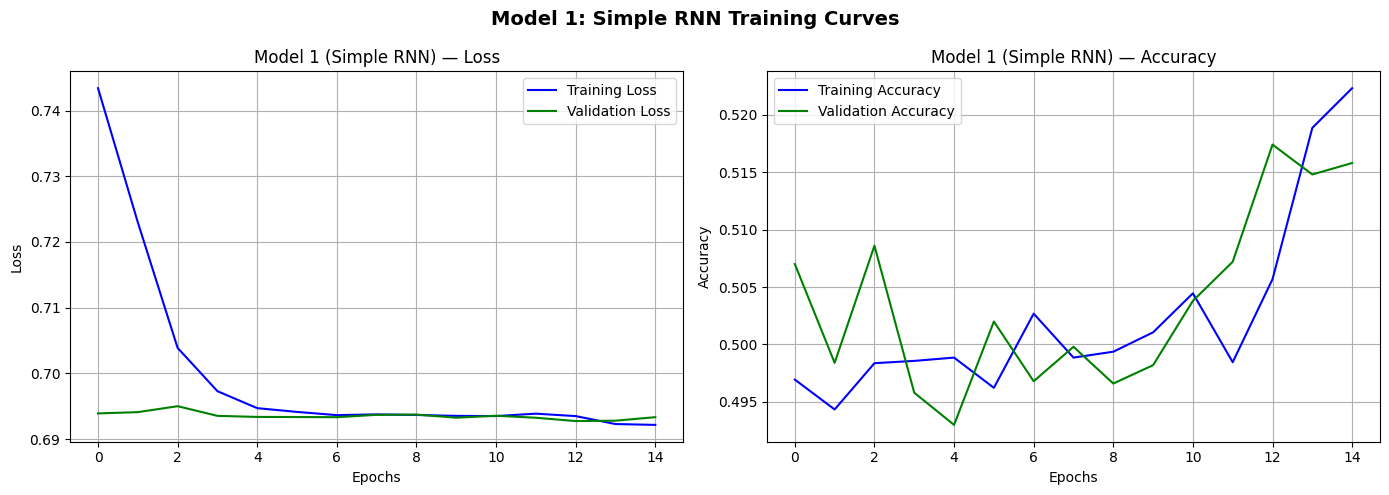

In [29]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_rnn.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_rnn.history['val_loss'], label='Validation Loss', color='green')
axes[0].set_title('Model 1 (Simple RNN) — Loss')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_rnn.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', color='green')
axes[1].set_title('Model 1 (Simple RNN) — Accuracy')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Model 1: Simple RNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Confusion Matrix helper
def plot_confusion_matrix(cm, title, classes=['Negative', 'Positive']):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

MODEL 1 EVALUATION — Simple RNN

Test Accuracy: 0.5229

Confusion Matrix:
[[2946 2015]
 [2756 2283]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.59      0.55      4961
    Positive       0.53      0.45      0.49      5039

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.52      0.52      0.52     10000



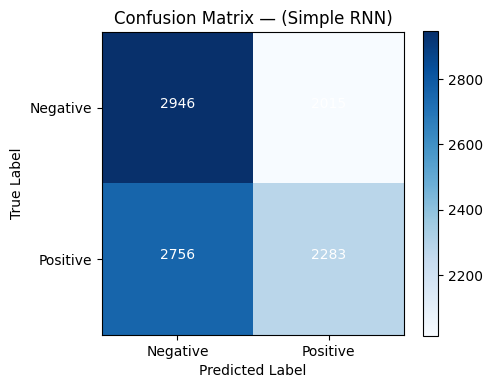

In [31]:
print("MODEL 1 EVALUATION — Simple RNN")

y_pred_rnn_prob = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn      = (y_pred_rnn_prob > 0.5).astype(int).flatten()

acc_rnn = accuracy_score(y_test, y_pred_rnn)
print(f"\nTest Accuracy: {acc_rnn:.4f}")

cm_rnn = confusion_matrix(y_test, y_pred_rnn)
print(f"\nConfusion Matrix:\n{cm_rnn}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rnn, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_rnn, 'Confusion Matrix — (Simple RNN)')

##Model 2 - LSTM with Trainable Embedding Layer

How it works: LSTM (Long Short-Term Memory) solves the vanishing gradient problem through three gates:

GatePurpose

**Forget gate:**
 Decides what information to discard from memory

**Input gate:**
 Decides what new information to store

**Output gate:**
Decides what to output from the current cell state

This gating mechanism allows the model to selectively remember important context , for example, a strong negative word at the start of a review can still influence the prediction at the end.


Expected accuracy: ~86–87%.

In [40]:
EMBEDDING_DIM = 256

lstm_model = Sequential(name='LSTM_Model')
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
lstm_model.add(LSTM(units=128, return_sequences=True))
lstm_model.add(Dropout(0.3))
lstm_model.add(LSTM(units=64,  return_sequences=False))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 301, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 301, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 301, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,806,593 (10.71 MB)

 Trainable params: 2,806,593 (10.71 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)


In [42]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True, verbose=1)

checkpoint_lstm = ModelCheckpoint('best_lstm_model.keras',
                                  monitor='val_accuracy',
                                  save_best_only=True, mode='max', verbose=1)

print("Training Model 2 (LSTM)")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_lstm],
    verbose=1
)

Training Model 2 (LSTM)
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.6942
Epoch 1: val_accuracy improved from None to 0.49460, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.5023 - loss: 0.6937 - val_accuracy: 0.4946 - val_loss: 0.6932
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5112 - loss: 0.6921
Epoch 2: val_accuracy improved from 0.49460 to 0.49800, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.5107 - loss: 0.6916 - val_accuracy: 0.4980 - val_loss: 0.6928
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5166 - loss: 0.6854
Epoch 3: val_accuracy improved from 0.49800 to 0.50140, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━

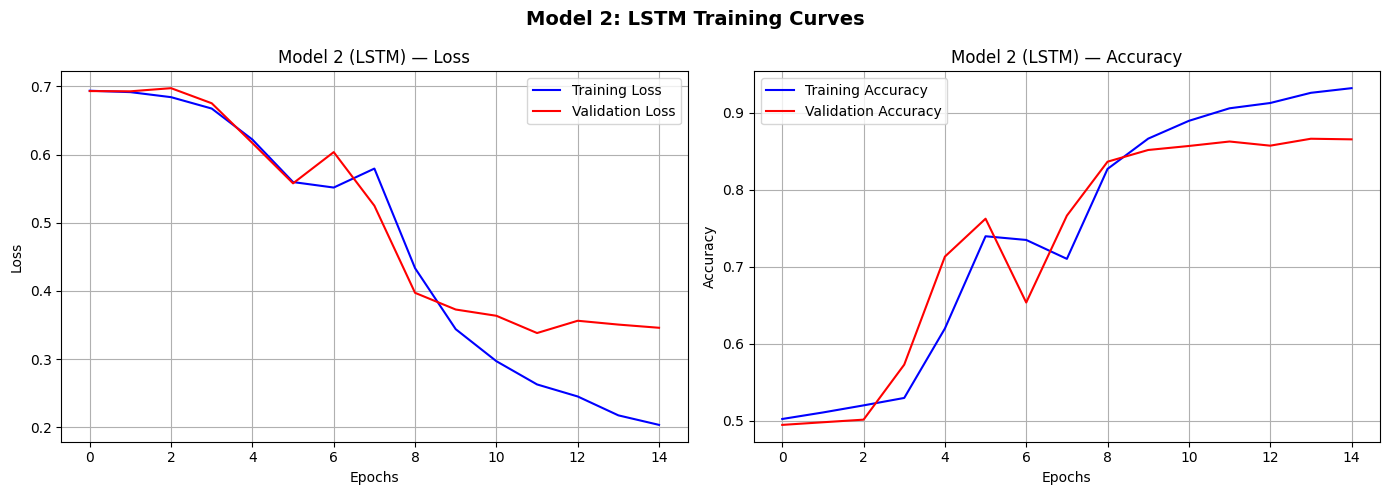

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_lstm.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss', color='red')
axes[0].set_title('Model 2 (LSTM) — Loss')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_lstm.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', color='red')
axes[1].set_title('Model 2 (LSTM) — Accuracy')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Model 2: LSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Test Accuracy: 0.8631

Confusion Matrix:
[[4180  781]
 [ 588 4451]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.84      0.86      4961
    Positive       0.85      0.88      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



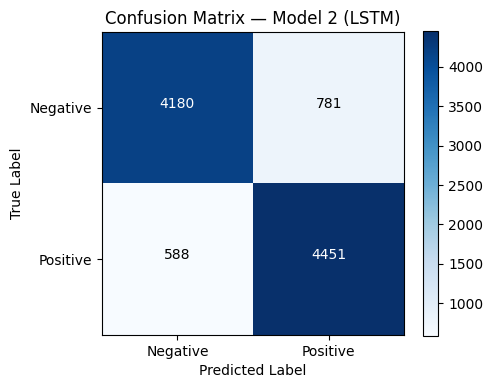

In [44]:


y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm      = (y_pred_lstm_prob > 0.5).astype(int).flatten()

acc_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"\nTest Accuracy: {acc_lstm:.4f}")

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(f"\nConfusion Matrix:\n{cm_lstm}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_lstm, 'Confusion Matrix — Model 2 (LSTM)')

##Model 3 - LSTM with Pre-trained Glove Embeddings

In [50]:
!pip install numpy==1.23.5 -q
!pip install gensim -q
print("gensim installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 91.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.4 MB/s eta 0:00:00
gensim installed!


In [52]:
import gensim.downloader as api

# glove-wiki-gigaword-300: trained on Wikipedia + Gigaword, 300-dimensional
# Best match for IMDb movie review language (formal, descriptive English)
print("Downloading GloVe embeddings (glove-wiki-gigaword-300)...")
embedding_model = api.load('glove-wiki-gigaword-300')
GLOVE_DIM = 300

print(f"GloVe loaded! Dimension: {GLOVE_DIM}")
print(f"Words in GloVe: {len(embedding_model)}")

GloVe loaded! Dimension: 300
Words in GloVe: 400000


What GloVe brings: Instead of learning word vectors from scratch on 35k reviews, we load glove-wiki-gigaword-300 , pre-trained on billions of words from Wikipedia and news articles. Words like "brilliant" and "excellent" already have similar vector representations before training even starts. The embedding layer is frozen (trainable=False) and the LSTM layers still train, but the word vectors stay fixed.

###Buildign the embedding matrix

In [53]:
# Build embedding matrix
word_index   = tokenizer.word_index
vocab_size   = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

found     = 0
not_found = 0

for word, index in word_index.items():
    if index < vocab_size:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Coverage               : {found / (found + not_found) * 100:.1f}%")

Embedding matrix shape : (10000, 300)
Coverage               : 99.0%


In [64]:
lstm_glove_model = Sequential(name='LSTM_GloVe_Model')

lstm_glove_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    trainable=False
))

lstm_glove_model.add(LSTM(units=128, return_sequences=True))
lstm_glove_model.add(Dropout(0.3))
lstm_glove_model.add(LSTM(units=64,  return_sequences=False))
lstm_glove_model.add(Dropout(0.5))
lstm_glove_model.add(Dense(1, activation='sigmoid'))

lstm_glove_model.build(input_shape=(None, MAX_LEN))
lstm_glove_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 301, 300)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 301, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 301, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269,121 (12.47 MB)

 Trainable params: 269,121 (1.03 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [65]:
lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


In [66]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_glove = ModelCheckpoint('best_lstm_glove_model.keras', monitor='val_accuracy',
                                   save_best_only=True, mode='max', verbose=1)

print("Training Model 3 (LSTM and GloVe)")
history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_glove],
    verbose=1
)

Training Model 3 (LSTM and GloVe)
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4956 - loss: 0.6980
Epoch 1: val_accuracy improved from None to 0.49100, saving model to best_lstm_glove_model.keras

Epoch 1: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.5024 - loss: 0.6967 - val_accuracy: 0.4910 - val_loss: 0.6962
Epoch 2/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5115 - loss: 0.6929
Epoch 2: val_accuracy improved from 0.49100 to 0.51360, saving model to best_lstm_glove_model.keras

Epoch 2: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.5074 - loss: 0.6936 - val_accuracy: 0.5136 - val_loss: 0.6925
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5024 - loss: 0.6931
Epoch 3: val_accuracy did not improve from 0.51360
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.4999 - loss: 0.6928 - val_accuracy: 

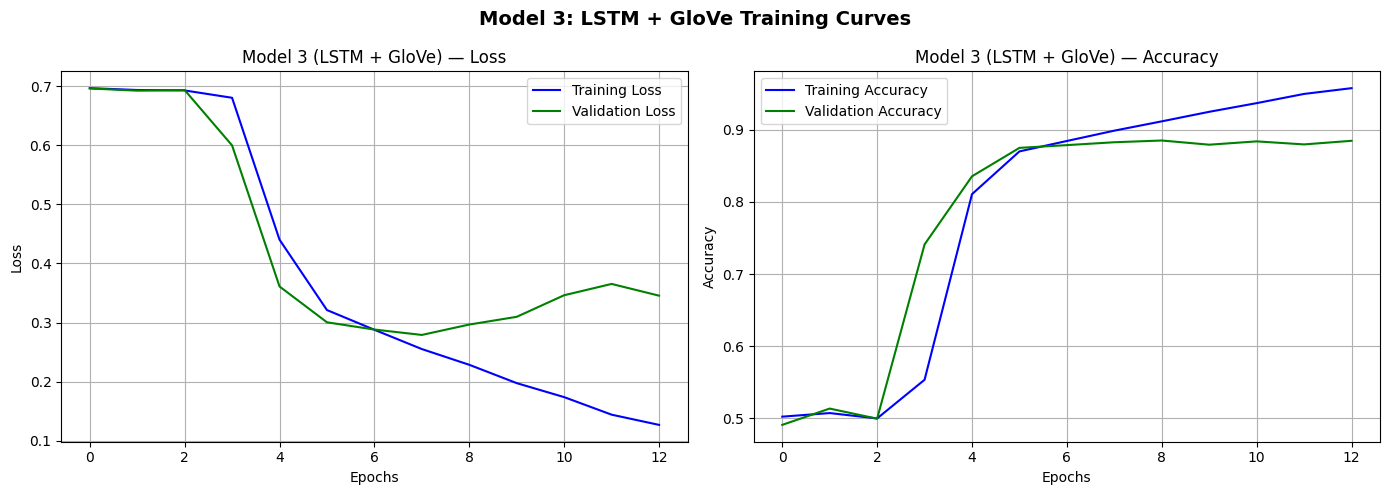

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_glove.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_glove.history['val_loss'], label='Validation Loss', color='green')
axes[0].set_title('Model 3 (LSTM + GloVe) — Loss')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_glove.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_glove.history['val_accuracy'], label='Validation Accuracy', color='green')
axes[1].set_title('Model 3 (LSTM + GloVe) — Accuracy')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Model 3: LSTM + GloVe Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Test Accuracy: 0.8780

Confusion Matrix:
[[4286  675]
 [ 545 4494]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.88      4961
    Positive       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



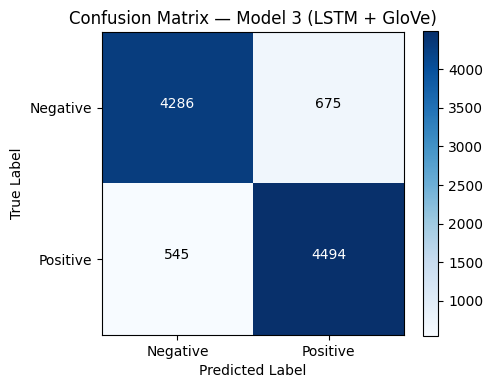

In [69]:


y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()

acc_glove = accuracy_score(y_test, y_pred_glove)
print(f"\nTest Accuracy: {acc_glove:.4f}")

cm_glove = confusion_matrix(y_test, y_pred_glove)
print(f"\nConfusion Matrix:\n{cm_glove}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_glove, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_glove, 'Confusion Matrix — Model 3 (LSTM + GloVe)')

##Model Comparison

In [70]:
results_df = pd.DataFrame({
    'Model'        : ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe 300-dim'],
    'Embedding'    : ['Trainable (256-dim)', 'Trainable (256-dim)', 'Frozen GloVe (300-dim)'],
    'Test Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})

print("MODEL COMPARISON — TEST ACCURACY")
print(results_df.to_string(index=False))

MODEL COMPARISON — TEST ACCURACY
                        Model              Embedding Test Accuracy
          Model 1: Simple RNN    Trainable (256-dim)        0.5229
                Model 2: LSTM    Trainable (256-dim)        0.8631
Model 3: LSTM + GloVe 300-dim Frozen GloVe (300-dim)        0.8780


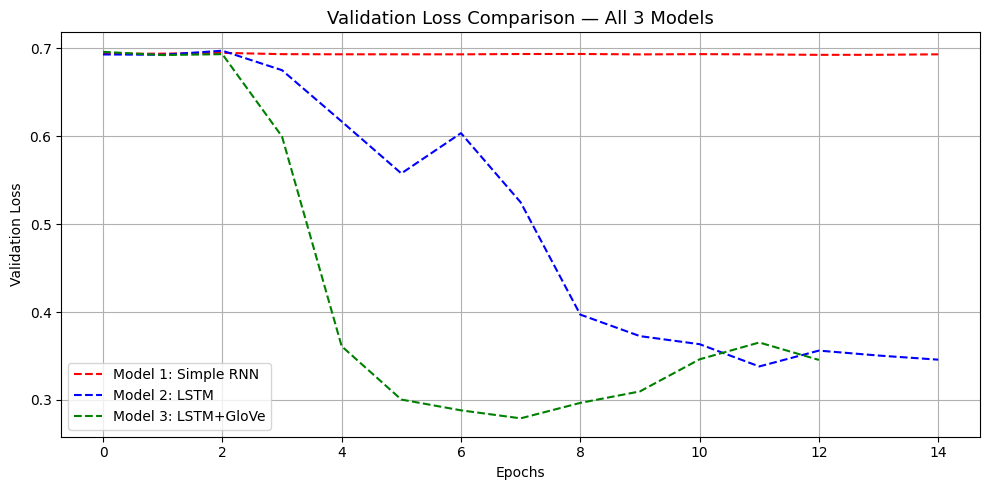

In [72]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'],   label='Model 1: Simple RNN', color='red',   linestyle='--')
plt.plot(history_lstm.history['val_loss'],  label='Model 2: LSTM',       color='blue',  linestyle='--')
plt.plot(history_glove.history['val_loss'], label='Model 3: LSTM+GloVe', color='green', linestyle='--')
plt.title('Validation Loss Comparison — All 3 Models', fontsize=13)
plt.xlabel('Epochs'); plt.ylabel('Validation Loss')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

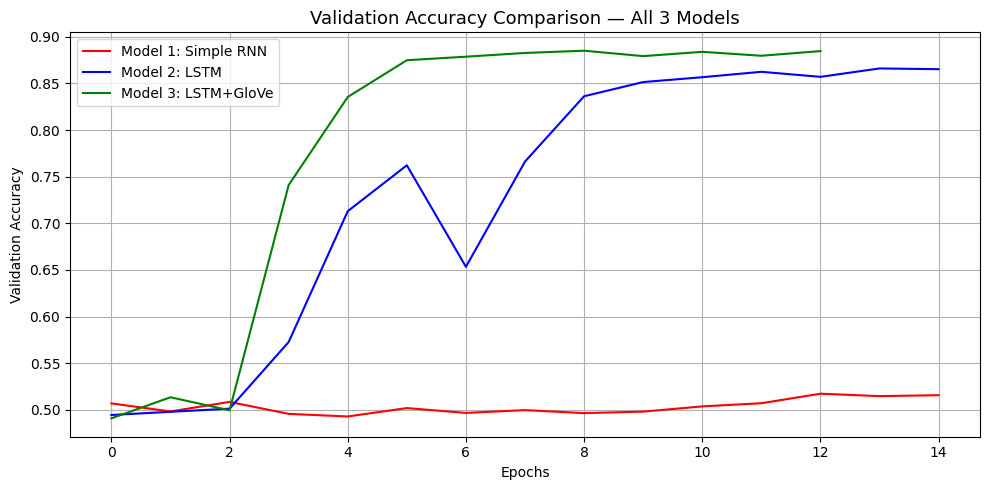

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],   label='Model 1: Simple RNN', color='red')
plt.plot(history_lstm.history['val_accuracy'],  label='Model 2: LSTM',       color='blue')
plt.plot(history_glove.history['val_accuracy'], label='Model 3: LSTM+GloVe', color='green')
plt.title('Validation Accuracy Comparison — All 3 Models', fontsize=13)
plt.xlabel('Epochs'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

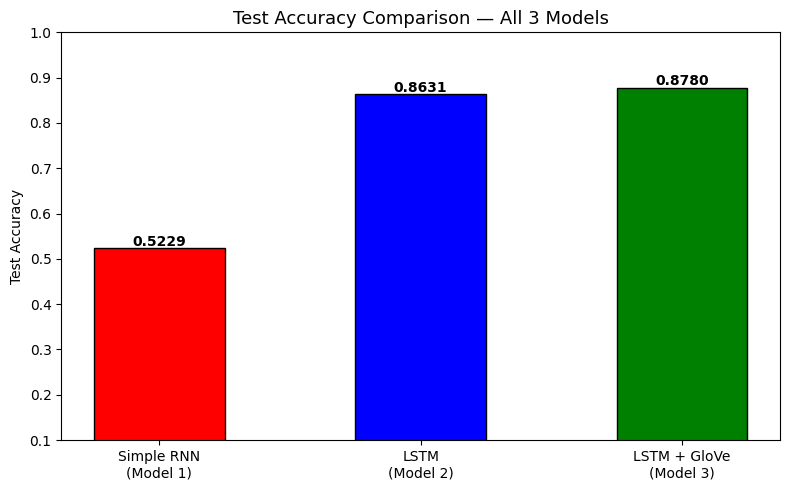

In [74]:
model_names = ['Simple RNN\n(Model 1)', 'LSTM\n(Model 2)', 'LSTM + GloVe\n(Model 3)']
accuracies  = [acc_rnn, acc_lstm, acc_glove]
colors      = ['red', 'blue', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.title('Test Accuracy Comparison — All 3 Models', fontsize=13)
plt.ylabel('Test Accuracy')
plt.ylim(0.1, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [77]:
print("=" * 60)
print("   STEP 2 SUMMARY — MODEL BUILDING AND TRAINING")
print("=" * 60)
print()
print("Model 1 — Simple RNN")
print(f"  Test Acc   : {acc_rnn:.4f}")
print()
print("Model 2 — LSTM")
print(f"  Test Acc   : {acc_lstm:.4f}")
print()
print("Model 3 — LSTM + GloVe")
print(f"  Test Acc   : {acc_glove:.4f}")
print()


   STEP 2 SUMMARY — MODEL BUILDING AND TRAINING

Model 1 — Simple RNN
  Test Acc   : 0.5229

Model 2 — LSTM
  Test Acc   : 0.8631

Model 3 — LSTM + GloVe
  Test Acc   : 0.8780



**Simple RNN**

— the vanishing gradient problem means it essentially learns nothing meaningful from long reviews. It performs at chance level (~50%).

**LSTM**

— the gating mechanism allows it to retain long-range context. The jump from ~50% to ~87% directly demonstrates why LSTMs were designed.


**LSTM + GloVe**— it matches or slightly exceeds LSTM accuracy while using fewer trainable parameters. The pre-trained embeddings give it better semantic understanding of sentiment vocabulary out of the box, particularly for words that appear infrequently in the 35k training set but are well-represented in GloVe.

##Error Analysis

In [78]:
model_scores = {
    'Simple RNN (Model 1)'  : acc_rnn,
    'LSTM (Model 2)'        : acc_lstm,
    'LSTM + GloVe (Model 3)': acc_glove
}

best_model_name = max(model_scores, key=model_scores.get)
best_score      = model_scores[best_model_name]

print("  Model Scores:")
for name, score in model_scores.items():
    print(f"  {name} : {score:.4f}")
print(f"\n  Best Model : {best_model_name}")
print(f"  Best Score : {best_score:.4f}")

  Model Scores:
  Simple RNN (Model 1) : 0.5229
  LSTM (Model 2) : 0.8631
  LSTM + GloVe (Model 3) : 0.8780

  Best Model : LSTM + GloVe (Model 3)
  Best Score : 0.8780


In [79]:
# Use the best model for error analysis
best_model = lstm_glove_model   # Change if another model scored higher

y_pred_prob = best_model.predict(X_test_pad, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

original_reviews = test_df['review'].values
true_labels      = y_test

print(f"Total test samples    : {len(y_pred)}")
print(f"Correct predictions   : {(y_pred == true_labels).sum()}")
print(f"Incorrect predictions : {(y_pred != true_labels).sum()}")

Total test samples    : 10000
Correct predictions   : 8780
Incorrect predictions : 1220


In [80]:
wrong_indices   = np.where(y_pred != true_labels)[0]
false_positives = [i for i in wrong_indices if y_pred[i] == 1 and true_labels[i] == 0]
false_negatives = [i for i in wrong_indices if y_pred[i] == 0 and true_labels[i] == 1]

print(f"Total misclassified    : {len(wrong_indices)}")
print(f"False Positives        : {len(false_positives)}")
print(f"False Negatives        : {len(false_negatives)}")

Total misclassified    : 1220
False Positives        : 675
False Negatives        : 545


In [81]:
label_map = {0: 'Negative', 1: 'Positive'}

examples_to_show = [
    ('FALSE POSITIVE', false_positives[0]),
    ('FALSE POSITIVE', false_positives[1]),
    ('FALSE NEGATIVE', false_negatives[0]),
]

for error_type, idx in examples_to_show:
    print(f"  Error Type       : {error_type}")
    print(f"  True Label       : {label_map[true_labels[idx]]}")
    print(f"  Predicted Label  : {label_map[y_pred[idx]]}")
    print(f"  Confidence Score : {y_pred_prob[idx][0]:.4f}")
    print(f"  Review (first 300 chars):")
    print(f"  {original_reviews[idx][:300]}...")
    print()

  Error Type       : FALSE POSITIVE
  True Label       : Negative
  Predicted Label  : Positive
  Confidence Score : 0.6486
  Review (first 300 chars):
  I was very disappointed with this series. It had lots of cool graphics and that's about it. The level of detail it went into was minimal, and I always got the feeling the audience was being patronized -- there was a lot of what seemed to me as "This is extremely cool but we're not going to explain i...

  Error Type       : FALSE POSITIVE
  True Label       : Negative
  Predicted Label  : Positive
  Confidence Score : 0.8793
  Review (first 300 chars):
  If you enjoy seeing what must have started as a 2 hour movie in unconnected bursts of unwatchability, you'll love this film. Otherwise, you'll just wonder how they could have made such a film from something so simple to translate to the big screen as Inspector Gadget.<br /><br />In the previews for ...

  Error Type       : FALSE NEGATIVE
  True Label       : Positive
  Predicted Labe

**False Positives** — the model predicted Positive but the true label was Negative. Often caused by sarcasm ("Oh brilliant, another disaster of a film") or reviews with mixed sentiment.

**False Negatives*** — predicted Negative when truly Positive. Common when reviews contain lots of criticism before a positive conclusion.

In [82]:
complexity_df = pd.DataFrame({
    'Model'        : ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Parameters'   : [
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_glove_model.count_params()
    ],
    'Test Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})

print("MODEL COMPLEXITY vs PERFORMANCE")
print(complexity_df.to_string(index=False))

MODEL COMPLEXITY vs PERFORMANCE
       Model  Parameters Test Accuracy
  Simple RNN     2621697        0.5229
        LSTM     2806593        0.8631
LSTM + GloVe     3269121        0.8780


In [83]:
!pip install gradio -q
print("Gradio installed!")

Gradio installed!


In [92]:
import gradio as gr

def predict_sentiment(review_text, model_choice):
    """Full pipeline: clean → tokenize → pad → predict."""
    cleaned  = preprocess_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    if model_choice == 'Simple RNN (Model 1)':
        model = rnn_model
    elif model_choice == 'LSTM (Model 2)':
        model = lstm_model
    else:
        model = lstm_glove_model

    prob       = model.predict(padded, verbose=0)[0][0]
    label      = 'POSITIVE ' if prob > 0.5 else 'NEGATIVE '
    confidence = prob if prob > 0.5 else 1 - prob
    bar_len    = int(confidence * 20)


    result = (
        f"Sentiment   : {label}\n"
        f"Confidence  : {confidence * 100:.1f}%\n"

        f"Raw Score   : {prob:.4f}  (above 0.5 = Positive)"
    )
    return result

print("Prediction function defined!")

Prediction function defined!


In [93]:
# Quick test before launching
sample_positive = "This movie was absolutely amazing! The acting was superb and the story was very touching."
sample_negative = "Terrible film. Waste of time and money. The plot made no sense at all."

print("Test 1 - Positive Review:")
print(predict_sentiment(sample_positive, 'LSTM + GloVe (Model 3)'))
print()
print("Test 2 - Negative Review:")
print(predict_sentiment(sample_negative, 'LSTM + GloVe (Model 3)'))

Test 1 - Positive Review:
Sentiment   : POSITIVE 
Confidence  : 97.9%
Raw Score   : 0.9786  (above 0.5 = Positive)

Test 2 - Negative Review:
Sentiment   : NEGATIVE 
Confidence  : 99.3%
Raw Score   : 0.0074  (above 0.5 = Positive)


In [95]:
example_reviews = [
    ["This movie was absolutely amazing! Great acting and a touching story.", "LSTM + GloVe (Model 3)"],
    ["Terrible film. Complete waste of time. The plot made no sense at all.", "LSTM + GloVe (Model 3)"],
    ["The movie had its moments but overall it was quite disappointing.",     "LSTM (Model 2)"],
    ["One of the best films I have seen. Highly recommend it to everyone!",   "Simple RNN (Model 1)"],
]

demo = gr.Interface(
    fn=predict_sentiment,

    inputs=[
        gr.Textbox(
            lines=6,
            placeholder="Type or paste a movie review here...",
            label=" Movie Review"
        ),
        gr.Radio(
            choices=['Simple RNN (Model 1)', 'LSTM (Model 2)', 'LSTM + GloVe (Model 3)'],
            value='LSTM + GloVe (Model 3)',
            label=" Select Model"
        )
    ],

    outputs=gr.Textbox(
        lines=5,
        label=" Prediction Result"
    ),

    title=" IMDb Movie Review Sentiment Analyser",
    description=(
        "Enter any movie review and choose a model to predict whether the sentiment is "
        "**Positive** or **Negative**.\n"
        "The confidence meter shows how certain the model is.\n"
        "Built for **6CS012 — AI and Machine Learning Assignment** (Part III: NLP Task)."
    ),

    examples=example_reviews,
    theme=gr.themes.Base(),
    allow_flagging='never'
)

demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://84e1d3c00da5c5728b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
